In [ ]:
!pip install openai

In [ ]:
import cv2
import numpy as np
import base64
import os
import json
from google.colab import drive
from google.colab.patches import cv2_imshow
from openai import OpenAI
from IPython.display import clear_output

In [ ]:
# permetti accesso a Google Drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Aimbot/'

Mounted at /content/drive


In [ ]:
# apri il file della chiave API di OpenAI
key_file = path + 'GPT5 - keys.json'
keys = open(key_file)
key_data = json.load(keys)
# crea il client locale per mandare i dati ai modelli di OpenAI
client = OpenAI(organization=key_data["org"], project=key_data["proj"], api_key=key_data["sk-proj"])

In [ ]:
def find_target(img, model = 'gpt-5.5', show = False):
  # img = immagine da elaborare
  # model = modello da usare per l'analisi
  # show = mostrare il frame elaborato?

  # dimensioni dell'immagine
  h, w = img.shape[:2]

  # numero di righe e colonne nella griglia da sovrapporre
  rows, cols = 16, 26

  #etichette delle colonne
  col_labels = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

  # colore in RGB delle scritte sovrapposte - rosso puro
  red = (0, 0, 255)

  # sovrappongo la griglia all'immagine
  # dimensione di un numero e di una lettera
  (w_num, h_num), _ = cv2.getTextSize('1', cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)
  (w_let, h_let), _ = cv2.getTextSize('W', cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)

  # offset in alto a sinistra prima delle intestazioni di riga e colonna
  v_off = h_let
  h_off = w_num

  # sovrappongo numeri di riga
  for i in range(rows + 1):
    x = 0
    y = int((h - v_off) / rows * i + v_off + h_num)
    cv2.putText(img, str(i + 1), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1.2, red, 3)

  # sovrappongo etichette di colonna
  for i in range(cols):
    x = int((w - h_off) / cols * i + h_off)
    y = h_let
    cv2.putText(img, col_labels[i], (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1.2, red, 3)

  # se è definito il modello a cui mandare la richiesta
  if model != None:
    # codifica dell'immagine in una stringa che possa essere inviata al modello
    _ , buffer = cv2.imencode('.png', img)
    base64_string = base64.b64encode(buffer).decode('utf-8')

    query="""
    Se nell'immagine vedi una figura umanoide con due gambe e una testa, parti dalla testa e guarda in modo perfettamente verticale verso l'alto nell'immagine e trova una lettera. Quella è la <colonna>.
    Se nell'immagine vedi una figura umanoide con due gambe e una testa, parti dalla testa e guarda in modo perfettamente orizzontale verso sinistra nell'immagine e trova un numero. Quella è la <riga>.
    Rispondi con <riga><colonna>.
    Se nell'immagine non vedi una figura umana rispondi con "--"
    """

    # invio al modello della richiesta di analisi e dell'immagine
    reply = client.responses.create(
        model=model,
        input=[{"role":"user", "content": [
            {"type": "input_text", "text": query},
            {"type": "input_image", "image_url": f"data:image/jpeg;base64,{base64_string}"}
        ]}]
    )

    # estraggo la risposta da quello che mi ha restituito il modello
    reply = reply.output_text.strip().upper()

    # sovrappongo la risposta all'immagine
    # dimensioni del testo della risposta
    (w_rep, h_rep), _ = cv2.getTextSize(reply, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 3)

    # coordinate a cui piazzare il testo
    x = w - w_rep
    y = h - 1
    cv2.putText(img, reply, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1.5, red, 3)

    # se ho trovato il target
    if reply != '--':

      # trasformo la risposta del tipo 10A nelle coordinate del centro della cella
      match = re.match(r"(\d+)([a-zA-Z]+)", reply)
      row_num = int(match.group(1)) - 1 # Indice 0-based per i calcoli
      col_label = match.group(2)
      col_idx = col_labels.index(col_label)

      # calcolo le dimensioni di una singola cella
      cell_width = (img.shape[1] - h_off) / cols
      cell_height = (img.shape[0] - v_off) / rows

      # calcolo il centro della cella
      center_x = int(h_off + (col_idx * cell_width) + (cell_width / 2))
      center_y = int(v_off + (row_num * cell_height) + (cell_height / 2))

      # disegno il cerchio
      cv2.circle(img, (center_x, center_y), 10, red, 2)

    else:
      center_x = 0
      center_y = 0

  else:
    reply = ''
    center_x = 0
    center_y = 0

  if show:
    cv2_imshow(img)

  return reply, center_x, center_y, img


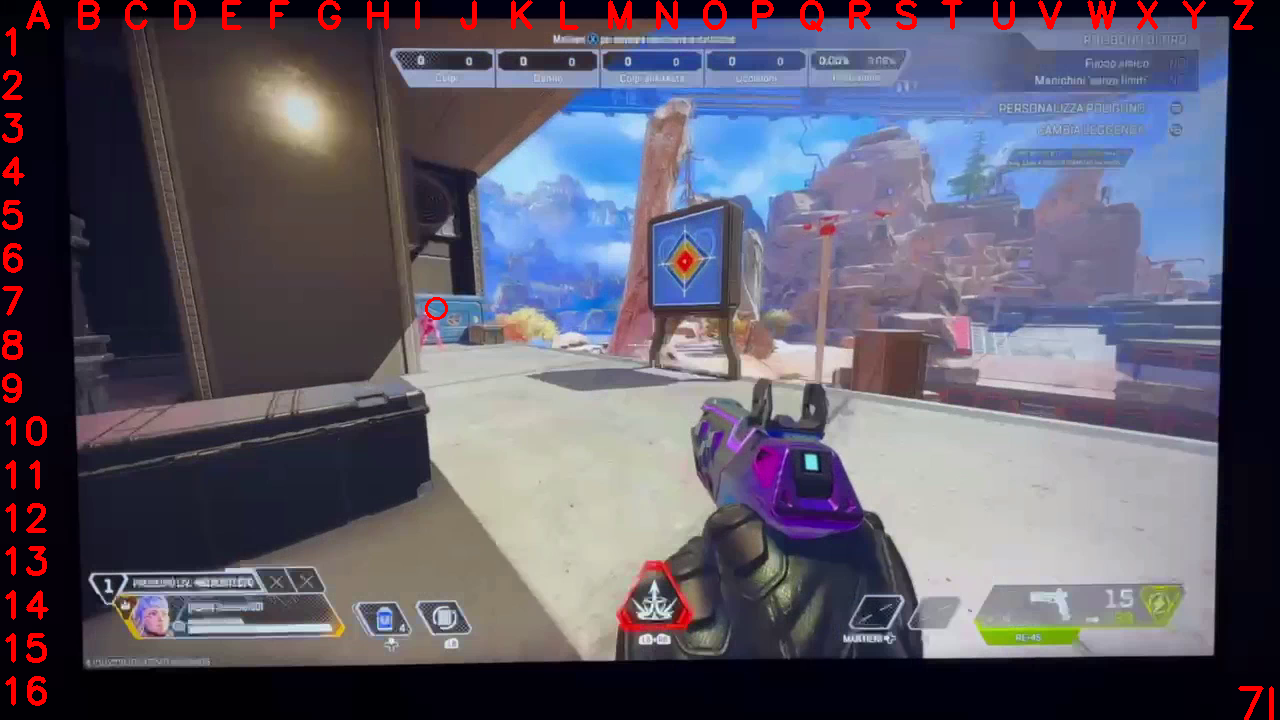

In [ ]:
# elabora un solo frame
# carica l'immagine
image_path = path + 'APEX11.png'
img = cv2.imread(image_path)

# trova il bersaglio
reply, x_target, y_target, img = find_target(img, show=True)


Frame: 150


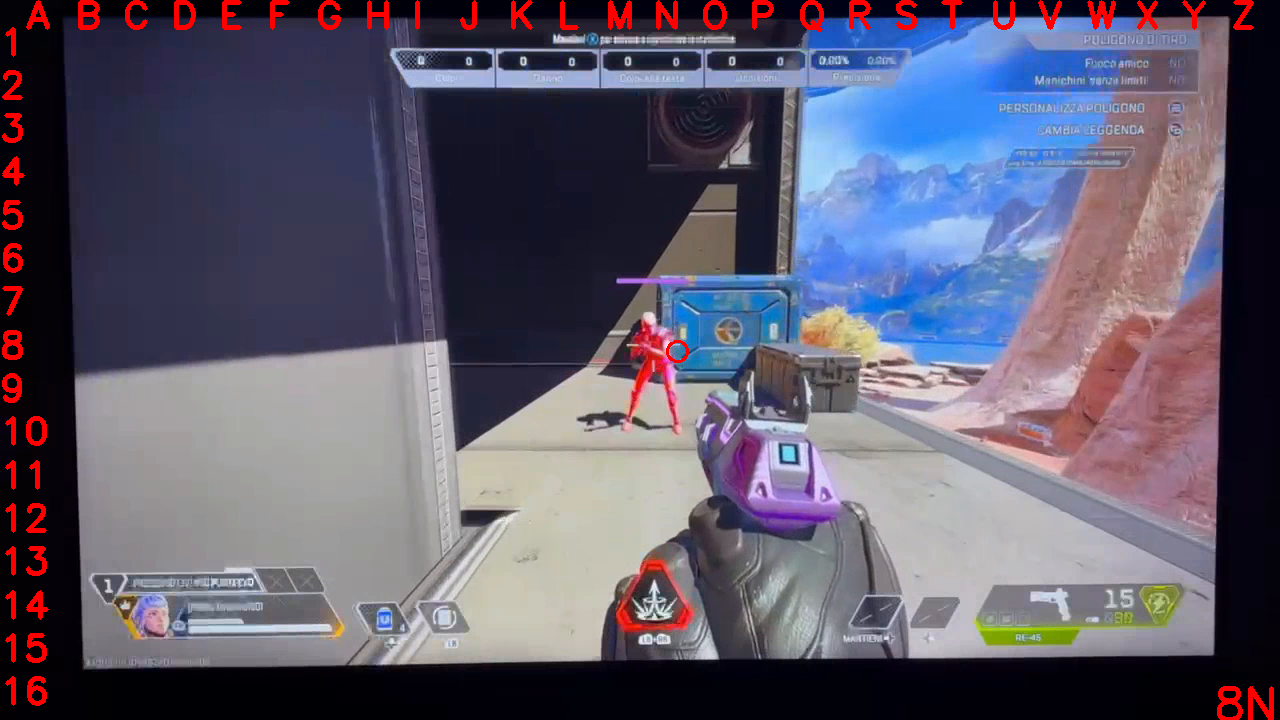

In [ ]:
# elabora un video e salva i frame con le sovrapposizioni
video_file = path + 'APEX-cut.mp4'

# dove mettere i famre elaborati
processed_frames = []
f = 0
# nel caso si volesse elaborare solo un frame ogni skip_f
skip_f = 0

# carica il video
cap = cv2.VideoCapture(video_file)

# ciclo su ogni frame del video caricato
while cap.isOpened():

  # estrarre il frame
  ret, img = cap.read()
  if not ret: break

  if f % (skip_f + 1) == 0:

    # se è da elaborare allora trova il bersaglio
    reply, x_target, y_target, img = find_target(img)

    # mostrare il frame con le sovrapposizioni
    clear_output(wait=True)
    print(f'Frame: {f}')
    cv2_imshow(img)

  else:
    # altrimenti limitati a sovrapporre la griglia
    reply, x_target, y_target, img = find_target(img, model=None)

  # conserva il risultato dell'elaborazione per dopo
  processed_frames.append(img)

  f += 1

# chiudi il file video
cap.release()

In [ ]:
# salva i frame con le sovrapposizioni come un nuovo video

# apri il video originale per prenderne le dimensioni
cap = cv2.VideoCapture(video_file)

fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# codifica un nuovo video in mp4 e con le stesse dimensioni
output_movie_file = path + 'processed_movie-1.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_movie_file, fourcc, 15, (width, height))

# aggiungi i frame elaborati prima
for f in processed_frames:
    out.write(f)

# chiudi il file video
out.release()
print(f"\nMovie saved as: {output_movie_file}")


Movie saved as: /content/drive/MyDrive/Aimbot/processed_movie-1.mp4
